Homework 5
==========
<link rel="stylesheet" href="/Users/pedrofatecha/GitHub/CodePF/ISYE6501_IntrotoAnalyticsModeling/02_Script/02_1_Function/styles.css">

>📌 Question 8.2
>Using crime data from http://www.statsci.org/data/general/uscrime.txt  (file uscrime.txt, description at http://www.statsci.org/data/general/uscrime.html ), use regression (a useful R function is lm or glm) to predict the observed crime rate in a city with the following data: </br>
> * M = 14.0
> * So = 0
> * Ed = 10.0
> * Po1 = 12.0
> * Po2 = 15.5
> * LF = 0.640
> * M.F = 94.0
> * Pop = 150
> * NW = 1.1
> * U1 = 0.120
> * U2 = 3.6
> * Wealth = 3200
> * Ineq = 20.1
> * Prob = 0.04
> * Time = 39.0 </br>
>
> Show your model (factors used and their coefficients), the software output, and the quality of fit.
> Note that because there are only 47 data points and 15 predictors, you’ll probably notice some overfitting.  We’ll see ways of dealing with this sort of problem later in the course.


In [137]:
library("kernlab")
library("kknn")
library("tidyr")
library("dplyr")
library("ggplot2")
library("plotly")
library("combinat")
library("ggplot2")


####Functions
read_data<-function(data.path = character()){
    # Reads the data from the given path and returns a data frame. In this case, the data is tab separated and has a header.
    data <- read.csv(data.path,header = TRUE,sep = "\t")
    return(data)

}
split_data<-function(data,split.ratio = numeric()){
    # Splits the data into training and testing sets based on the given split ratio. The split ratio is the proportion of the data that will be used for training.
    set.seed(123) # Setting seed for reproducibility
    sample_index <- sample(1:nrow(data), size = floor(split.ratio * nrow(data)))
    train_data <- data[sample_index, ]
    test_data <- data[-sample_index, ]
    return(list(train = train_data, test = test_data))
}

build_model<-function(train_data,target_variable){
    # Builds a linear regression model using the training data. The target variable is "Crime" and the predictors are all other variables in the dataset.
    model <- lm(target_variable, data = train_data)
   
    return(model)
}

Best_predictors<-function(Model_bilt=lm()){
    
    result_model<-summary(Model_bilt)

    preditors_to_use<-rownames(result_model$coefficients[result_model$coefficients[,"Pr(>|t|)"]>0.05,])
    Coef_values<-result_model$coefficients[result_model$coefficients[,"Pr(>|t|)"]>0.05,]

    preditors_to_use<-c(preditors_to_use)

    cat("Best predictors to use in the model are: \n")
    if (length(preditors_to_use) == 0) {
        cat("No predictors are statistically significant at the 0.05 level.\n")
    } else {
    for (i in 1:length(preditors_to_use)) {
        cat(preditors_to_use[i], "with coefficient", Coef_values[i, "Estimate"], "\n")
    }
    }
    cat("\n")
    cat("Predictors to exclude from the model are: \n")
    for (i in 1:nrow(result_model$coefficients)) {
        if (result_model$coefficients[i, "Pr(>|t|)"] <= 0.05) {
            cat(rownames(result_model$coefficients)[i], "\n")
        }
    }

    return (list(best_predictors = preditors_to_use, coefficients = Coef_values))

}

evaluate_model<-function(model,test_data,target_variable = character()){
    # Evaluates the model on the test data and returns the Mean Squared Error (MSE) of the predictions.
    predictions <- predict(model, newdata = test_data)
    
    actuals <- test_data[[target_variable]]
    mse <- mean((predictions - actuals)^2)
    return(predictions)
}

accuracy_lm <- function(model) {
  # model: an object of class "lm"
  
  s <- summary(model)
  r2 <- s$r.squared              # R-squared
  acc_percent <- 100 * r2        # interpret as "% accuracy"
  
  list(
    r_squared   = r2,
    accuracy_pct = acc_percent
  )
}





evaluate_models <- function(data, y, preds) {
  results <- list()
  idx <- 1
  
  # loop over model size: 1 predictor, 2 predictors, ...
  for (k in 1:length(preds)) {
    combs <- combn(preds, k, simplify = FALSE)
    
    for (vars in combs) {
      formula_txt <- paste(y, "~", paste(vars, collapse = " + "))
      fit <- lm(as.formula(formula_txt), data = data)
      acc <- accuracy_lm(fit)
      
      results[[idx]] <- data.frame(
        model_id      = idx,
        n_predictors  = k,
        predictors    = paste(vars, collapse = " + "),
        r_squared     = acc$r_squared,
        accuracy_pct  = acc$accuracy_pct,
        stringsAsFactors = FALSE
      )
      idx <- idx + 1
    }
  }
  
  do.call(rbind, results)
}


In [138]:

path_data_toread<-"/Users/pedrofatecha/GitHub/CodePF/ISYE6501_IntrotoAnalyticsModeling/01_Data/Homework5_ISYE6501/uscrime.txt"

Crime_data_set <- read_data(path_data_toread)

data_split<-split_data(Crime_data_set, split.ratio = 0.7)

regression_model <- build_model(train_data = data_split$train, target_variable = Crime ~ .)

Best_predictors(regression_model)

accuracy_lm(regression_model)


Best predictors to use in the model are: 
M with coefficient 81.64195 
So with coefficient 38.70473 
Po1 with coefficient 165.4284 
Po2 with coefficient -117.1049 
LF with coefficient -4137.017 
Pop with coefficient 1.860539 
NW with coefficient 14.73603 
U1 with coefficient -10324.59 
U2 with coefficient 122.1021 
Wealth with coefficient 0.1025678 
Ineq with coefficient 48.07225 
Prob with coefficient 1456.17 
Time with coefficient 12.08994 

Predictors to exclude from the model are: 
(Intercept) 
Ed 
M.F 


,Estimate,Std. Error,t value,Pr(>|t|)
M,8.164195e+01,49.2927707,1.6562662,0.11714489
So,3.870473e+01,229.4534226,0.1686823,0.86816056
Po1,1.654284e+02,128.5451390,1.2869288,0.21642691
Po2,-1.171049e+02,142.9266475,-0.8193358,0.42463183
LF,-4.137017e+03,2299.9454941,-1.7987458,0.09094894
Pop,1.860539e+00,1.9221215,0.9679613,0.34746877
NW,1.473603e+01,10.2733121,1.4343989,0.17071495
U1,-1.032459e+04,5618.7357081,-1.8375293,0.08477493
U2,1.221021e+02,103.2743601,1.1823080,0.25435661
Wealth,1.025678e-01,0.1370014,0.7486621,0.46492511


$r_squared
[1] 0.8825041

$accuracy_pct
[1] 88.25041

In [133]:

Equation_Excluded_predictor<- Crime ~ M + So + Po1 + Po2 + LF + Pop + NW + U1 + U2 + Wealth + Ineq + Prob + Time

regression_model <- build_model(train_data = data_split$train, target_variable = Equation_Excluded_predictor)
summary(regression_model)
Best_predictors(regression_model)

accuracy_lm(regression_model)


Call:
lm(formula = target_variable, data = train_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-548.40  -65.77   -1.93  105.65  402.86 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)  
(Intercept) -4847.4944  1985.9808  -2.441   0.0252 *
M              69.0075    66.6960   1.035   0.3145  
So            179.1384   304.0101   0.589   0.5630  
Po1            73.3024   170.7560   0.429   0.6728  
Po2            28.1830   187.2703   0.150   0.8820  
LF           1802.4223  2329.8162   0.774   0.4492  
Pop            -0.7923     2.3056  -0.344   0.7351  
NW              4.2900    13.1999   0.325   0.7489  
U1           2090.8103  5894.7591   0.355   0.7269  
U2              3.6931   133.0556   0.028   0.9782  
Wealth          0.2964     0.1744   1.699   0.1065  
Ineq           57.0006    36.6744   1.554   0.1375  
Prob         1044.5900  5139.2137   0.203   0.8412  
Time           -1.6638    12.4203  -0.134   0.8949  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0

Best predictors to use in the model are: 
M with coefficient 69.00749 
So with coefficient 179.1384 
Po1 with coefficient 73.30241 
Po2 with coefficient 28.18302 
LF with coefficient 1802.422 
Pop with coefficient -0.7922533 
NW with coefficient 4.290032 
U1 with coefficient 2090.81 
U2 with coefficient 3.693147 
Wealth with coefficient 0.296433 
Ineq with coefficient 57.0006 
Prob with coefficient 1044.59 
Time with coefficient -1.663842 

Predictors to exclude from the model are: 
(Intercept) 


,Estimate,Std. Error,t value,Pr(>|t|)
M,69.0074872,66.696004,1.03465700,0.3145306
So,179.1383535,304.010083,0.58925136,0.5630160
Po1,73.3024054,170.756029,0.42928151,0.6728126
Po2,28.1830230,187.270276,0.15049384,0.8820486
LF,1802.4222757,2329.816153,0.77363284,0.4491897
Pop,-0.7922533,2.305587,-0.34362325,0.7351108
NW,4.2900315,13.199853,0.32500601,0.7489236
U1,2090.8102733,5894.759122,0.35468969,0.7269437
U2,3.6931472,133.055597,0.02775642,0.9781618
Wealth,0.2964330,0.174435,1.69938965,0.1064618


$r_squared
[1] 0.7570579

$accuracy_pct
[1] 75.70579

In [107]:


Equation_Excluded_predictor<- Crime ~ M + Ed + Po1 + U2 + Ineq + Prob

regression_model <- build_model(train_data = data_split$train, target_variable = Equation_Excluded_predictor)
summary(regression_model)
Best_predictors(regression_model)

accuracy_lm(regression_model)


Call:
lm(formula = target_variable, data = train_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-405.72  -93.02  -32.93  112.04  631.68 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -5550.03    1209.77  -4.588 0.000108 ***
M             109.59      44.49   2.464 0.020987 *  
Ed            220.20      62.97   3.497 0.001779 ** 
Po1           113.29      17.95   6.313 1.32e-06 ***
U2             96.47      60.03   1.607 0.120588    
Ineq           73.56      19.67   3.741 0.000961 ***
Prob        -2332.43    2703.82  -0.863 0.396534    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 222 on 25 degrees of freedom
Multiple R-squared:  0.7788,	Adjusted R-squared:  0.7257 
F-statistic: 14.67 on 6 and 25 DF,  p-value: 4.003e-07


Best predictors to use in the model are: 
(Intercept) with coefficient -5550.028 
M with coefficient 109.5942 
Ed with coefficient 220.1976 
Po1 with coefficient 113.2946 
Ineq with coefficient 73.5635 

Predictors to exclude from the model are: 
U2 
Prob 


,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),-5550.0276,1209.76602,-4.587687,1.084966e-04
M,109.5942,44.48602,2.463564,2.098680e-02
Ed,220.1976,62.96847,3.496950,1.779048e-03
Po1,113.2946,17.94508,6.313406,1.316332e-06
Ineq,73.5635,19.66605,3.740635,9.613996e-04


$r_squared
[1] 0.7787676

$accuracy_pct
[1] 77.87676

,model_id,n_predictors,predictors,r_squared,accuracy_pct
,<dbl>,<int>,<chr>,<dbl>,<dbl>
32767,32767,15,Ed + M.F + M + So + Po1 + Po2 + LF + Pop + NW + U1 + U2 + Wealth + Ineq + Prob + Time,0.8030868,80.30868


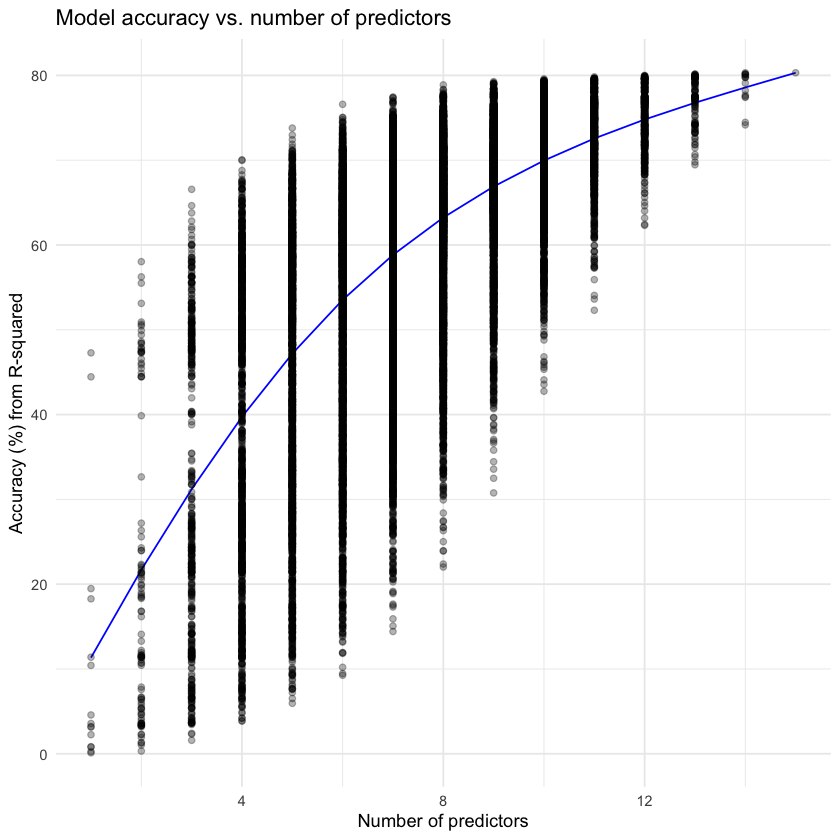

In [134]:


#
preds <- c("Ed","M.F","M", "So", "Po1","Po2","LF", "Pop" , "NW" ,"U1", "U2", "Wealth", "Ineq" , "Prob",  "Time")



results_tbl <- evaluate_models(Crime_data_set, y = "Crime", preds = preds)

# 4) Plot accuracy vs. number of predictors
ggplot(results_tbl, aes(x = n_predictors, y = accuracy_pct)) +
  geom_line(stat = "summary", fun = mean, color = "blue") +
  geom_point(alpha = 0.3) +
  labs(
    x = "Number of predictors",
    y = "Accuracy (%) from R-squared",
    title = "Model accuracy vs. number of predictors"
  ) +
  theme_minimal()

results_tbl[which.max(results_tbl$accuracy_pct), ]



In [139]:
results_tbl_Test <- evaluate_models(data_split$test, y = "Crime", preds = preds)

results_tbl_Test[which.max(results_tbl_Test$accuracy_pct), ]

#results_tbl <- evaluate_models(data_split$test, y = "Crime", preds = preds)


,model_id,n_predictors,predictors,r_squared,accuracy_pct
,<dbl>,<int>,<chr>,<dbl>,<dbl>
32752,32752,14,Ed + M.F + M + So + Po1 + Po2 + LF + Pop + NW + U1 + U2 + Wealth + Ineq + Prob,1,100
